# Hệ thống kiểm tra chứng từ giao nhận KIDO — **TẦNG 1: Chuẩn hoá ảnh**

> Notebook này là **vỏ mỏng**: nó không chứa thuật toán. Toàn bộ xử lý nằm trong
> `tools/stage1_normalizer.py` và được chạy qua đúng runner chính thức
> `tools/run_stage1_on_form_samples.py` (cùng `Stage1Config` nới lỏng cho ảnh demo, cùng
> `ProcessPoolExecutor(6)`). Notebook chỉ **gọi** runner rồi **đọc lại artifact trên đĩa**.
>
> Sinh bởi `tools/generate_nb1.py`, chạy + điền output bởi `tools/run_and_populate_nb1.py`.
> Bản notebook cũ (chạy lần cuối 14/09, chứa ~100KB bản sao code riêng, lệch mọi bản sửa 27/09)
> đã được **chuyển** sang `scratch/_archive_notebooks/`.

**Nguyên tắc:** mọi con số trong notebook này là **số đo được trong cell** hoặc đọc từ artifact.
Không có nhãn tự chấm kiểu "✅ 100%". Kiểm chứng nào không chạy được thì in rõ là **BỎ QUA**,
không in PASS.

Toàn bộ xử lý là **luật cứng (rule-based) bằng OpenCV + Tesseract**, không train model nào, chạy CPU.

## 1. Vị trí của Tầng 1 trong hệ thống

| Thành phần | Nhiệm vụ | Đầu ra |
|---|---|---|
| **Tầng 1** (notebook này) | Chuẩn hoá ảnh: phân biệt scan/ảnh chụp, cổng 4 góc, nắn A4, xoay 4 hướng, cân sáng **bảo toàn mộc đỏ & mực xanh** | ảnh chuẩn hoá + JSON 1 trang |
| Tầng 2 | Phân loại 2 trục (doc_type × system) + bóc tách trường khoá | `stage2_out` |
| Tầng 3 | Ghép đa trang, gom Lô chuyến, gom hồ sơ đơn hàng, đối soát | `stage3_batched_manifest.json` |
| Tầng 3b | Dò vùng ký động theo biểu mẫu | bounding box cho Tầng 4 |
| Tầng 4 | Verify chữ ký / mộc | phán quyết |

Tầng 1 **không** quyết định "ảnh này là biểu mẫu nào" — đó là việc của Tầng 2. Tầng 1 chỉ bảo đảm
mọi ảnh đưa lên Tầng 2 đều **đọc được, đúng hướng, đủ nội dung**, và chặn ảnh không dùng được.

## 2. Pipeline 16 bước (`process_one` trong `tools/stage1_normalizer.py`)

```
Đọc ảnh
 → mặt nạ giấy GrabCut ĐỒNG THUẬN 3 seed (20250913, 424242, 777) + majority vote
 → dò tứ giác 3 chiến lược (contour/Canny · GrabCut nền · giao điểm Hough)
 → đo ink_outside_quad (% nét chữ bị tứ giác cắt mất)
 → đo chất lượng (độ nét, lóa, mật độ mực, độ đều sáng)
 → phân loại scan / photo (đặc trưng có trọng số, không train)
 → cổng 4 góc (chỉ áp cho ảnh có vành nền)
 → nắn phối cảnh về khổ A4
 → xoay thô 0/90/180/270 + khử nghiêng tinh
 → cắt viền trắng
 → cân sáng (chỉ kênh V của HSV — giữ nguyên H, S)
 → kiểm chứng mực (ink_check: % đỏ / % xanh trước & sau)
 → đo DPI hiệu dụng (trên cạnh giấy trong ẢNH GỐC)
 → ghi ảnh + gán status / action
```

### Thiết kế đáng giữ (lý lẽ, không phải số)

* **`ink_outside_quad`** đo trực tiếp "% nét chữ bị cắt mất" thay vì chỉ IoU. Đúng vấn đề nghiệp vụ:
  dải rìa giấy chứa chữ ký và mộc. Bài học của các bản trước: *thước đo làm từ chính thứ cần đo*
  (IoU tứ giác so với mặt nạ do chính hệ thống sinh) luôn báo đẹp — nên JSON có cờ
  `iou_is_self_referential`.
* **GrabCut 3 seed + majority vote**: không chỉ để tái lập, mà biến **độ bất đồng giữa 3 seed thành
  tín hiệu cảnh báo** (`agreement_reject` / `agreement_warn`).
* **DPI hiệu dụng** tính trên cạnh giấy trong **ảnh gốc** chia 11.69 inch — chống ảo giác
  "resize lên 2200px là đủ nét". JSON ghi cả `effective_dpi` lẫn `nominal_dpi_a4` + cờ `upscaled`.
* **Không bao giờ nhị phân hoá / chuyển xám.** Tầng 4 phải tìm mộc tròn đỏ và chữ ký mực xanh.
  Cân sáng chỉ làm phẳng kênh V; `white_balance_on_paper` chặn gain trong khoảng hẹp;
  `ink_check` tự đo % pixel đỏ/xanh trước–sau để phát hiện nếu chuẩn hoá lỡ làm mất mộc.
* **Chuỗi xoay 3 lớp**: trục chữ (phương sai hình chiếu) → **OCR Lexical Guard** (từ khoá trong
  `config/stage1_orientation_keywords.json`) → OSD Tesseract (chỉ tin khi conf ≥ `osd_min_confidence`
  **và** `script == 'Latin'`) → fallback `flip_score`.
* **"Thà không xoay còn hơn xoay sai"**: sau khi nắn phối cảnh, khử nghiêng tinh bị giới hạn nhỏ;
  không đủ đường kẻ hoặc các đường không đồng thuận → trả 0°. Không chắc hướng 180° → cờ
  `rotation.needs_verification_180` để Tầng 2 xác nhận lại bằng OCR.
* **Ảnh scan được miễn luật đủ 4 góc** — tờ giấy trùm kín mặt kính là bình thường. Quyết định
  "có nắn / có kiểm 4 góc" dựa trên **hình học đo được** (quanh giấy có vành nền khác chất liệu
  không — `ring_test`), không chỉ dựa vào nhãn scan/photo.

## 3. DPI thấp là **CẢNH BÁO**, không phải **TỪ CHỐI** (bài học quan trọng)

Ban đầu DPI thấp **một mình** đã đủ gán `CHUP_LAI`. Thực nghiệm (AGENTS.md mục 3.F) chứng minh sai:
8 trang bị loại chỉ vì DPI 27–40 vẫn được Tầng 2 phân loại đúng; tệ hơn, loại 1 trang **làm gãy cả
bộ hồ sơ đa trang** của trang còn lại vốn tốt (multi-page Recall Tầng 3 tụt 100% → 71.43%).

⇒ Quy tắc hiện tại: **chỉ từ chối khi DPI thấp ĐI KÈM một lỗi chất lượng khác.** Nếu mọi tiêu chí
khác đều đạt → `CANH_BAO` + cờ `low_resolution: True`, vẫn chuyển Tầng 2. Cell tổng hợp bên dưới
đếm cờ này trực tiếp từ JSON.

### Gác cổng 3 mức

| `status` | `action` | Ý nghĩa |
|---|---|---|
| `DAT` | `CHUYEN_TANG_2` | không có vấn đề |
| `CANH_BAO` | `CHUYEN_TANG_2` | xử lý được nhưng đáng ngờ — gắn cờ cho người kiểm tra |
| `CHUP_LAI` | `YEU_CAU_CHUP_LAI` | mất nội dung / không đọc được — **chặn**, không được rò sang Tầng 2 |

Lỗi contract cũ (AGENTS.md 9.1): runner từng **ghi đè** `action` theo `norm_img is not None`, nên
trang `CHUP_LAI` vẫn bị gán `CHUYEN_TANG_2` và rò sang Tầng 2. Cell "Kiểm contract" bên dưới
**assert thật** điều này trên từng JSON.

### Cảnh báo về dữ liệu demo — đọc trước khi nhìn số

72 ảnh trích từ file Excel `docs/Copy of HUONG DAN CHUNG TU GIAO NHAN.xlsx` bị nén nặng
(~45–150 DPI hiệu dụng). Hệ thống thật cần scan ≥ 200–300 DPI. Vì vậy runner chính thức dùng
`Stage1Config` **nới lỏng** (in nguyên văn ở cell dưới). **Không chốt ngưỡng nào trên bộ ảnh này.**

## 4. Tham số chạy

| Biến môi trường | Mặc định | Ý nghĩa |
|---|---|---|
| `KIDO_T1_OUT_DIR` | `output/stage1_out` | thư mục gốc đầu ra (artifact chính thức Tầng 2 đọc) |
| `KIDO_T1_REFERENCE_DIR` | *(rỗng)* | lần chạy trước để kiểm tái lập; rỗng ⇒ in **BỎ QUA** |

Cách chạy chính thức (agent chạy chuỗi): xem `tools/run_and_populate_nb1.py --help`.

In [1]:
import os, sys, time, json, glob, hashlib
from pathlib import Path
from collections import Counter

# Notebook nằm ở gốc dự án; runner chính thức dùng đường dẫn tương đối "output/form_samples".
PROJECT_DIR = Path(os.environ.get("KIDO_PROJECT_DIR", os.getcwd())).resolve()
os.chdir(PROJECT_DIR)
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

OUT_DIR = os.environ.get("KIDO_T1_OUT_DIR", "output/stage1_out")
REFERENCE_DIR = os.environ.get("KIDO_T1_REFERENCE_DIR", "") or None
BATCH_ID = "form_samples"
INPUT_DIR = "output/form_samples"

import numpy as np
import pandas as pd
import cv2
import tools.stage1_normalizer as s1
import tools.run_stage1_on_form_samples as rs1

print("PROJECT_DIR   :", PROJECT_DIR)
print("OUT_DIR       :", OUT_DIR)
print("REFERENCE_DIR :", REFERENCE_DIR)
print("stage1 module :", Path(s1.__file__).relative_to(PROJECT_DIR), "| STAGE1_VERSION =", s1.STAGE1_VERSION)
print("runner        :", Path(rs1.__file__).relative_to(PROJECT_DIR))
print("Ảnh đầu vào   :", len(glob.glob(f"{INPUT_DIR}/*.png")), "file .png trong", INPUT_DIR)
print("Lexical guard :", s1.lexical_guard_status())

PROJECT_DIR   : D:\OCR_chuki
OUT_DIR       : output/stage1_out
REFERENCE_DIR : scratch/_nb/chain/run1/stage1_out
stage1 module : tools\stage1_normalizer.py | STAGE1_VERSION = 1.0.0
runner        : tools\run_stage1_on_form_samples.py
Ảnh đầu vào   : 72 file .png trong output/form_samples
Lexical guard : {'enabled': True, 'n_keywords': 35, 'source': 'D:\\OCR_chuki\\config\\stage1_orientation_keywords.json', 'error': None}


## 5. Cấu hình — lấy **nguyên văn** từ runner chính thức

Notebook không tự đặt ngưỡng. Đoạn dưới in đúng khối `Stage1Config(...)` trong
`run_stage1_on_form_samples.main()` (đây là cấu hình được dùng thật), rồi in giá trị mặc định của
`Stage1Config` trong module lõi để thấy runner nới lỏng những gì.

In [2]:
import inspect, dataclasses, re
src = inspect.getsource(rs1.main)
m = re.search(r"cfg = s1\.Stage1Config\((.*?)\n    \)", src, re.S)
print("=== Stage1Config trong run_stage1_on_form_samples.main() ===")
print("cfg = s1.Stage1Config(" + (m.group(1) if m else "  <KHÔNG TÌM THẤY — kiểm lại runner>") + "\n)")

overrides = dict(re.findall(r"(\w+)\s*=\s*([^,\n]+)", m.group(1))) if m else {}
defaults = {f.name: f.default for f in dataclasses.fields(s1.Stage1Config)
            if f.default is not dataclasses.MISSING}
rows = [{"tham_so": k, "mac_dinh_module": defaults.get(k, "(không có mặc định)"), "runner_dat": v}
        for k, v in overrides.items()]
pd.DataFrame(rows)

=== Stage1Config trong run_stage1_on_form_samples.main() ===
cfg = s1.Stage1Config(
        input_dir="output/form_samples",
        output_dir=args.out_dir,
        batch_mode="folder",
        min_long_edge=500,
        warn_long_edge=800,
        dpi_reject=40.0,
        dpi_warn=70.0,
        blur_reject=25.0,
        blur_warn=70.0,
        save_debug=True
)


,tham_so,mac_dinh_module,runner_dat
0,input_dir,D:\OCR_chuki\docs,"""output/form_samples"""
1,output_dir,D:\OCR_chuki\output\stage1_out,args.out_dir
2,batch_mode,folder,"""folder"""
3,min_long_edge,900,500
4,warn_long_edge,1400,800
5,dpi_reject,100.0,40.0
6,dpi_warn,150.0,70.0
7,blur_reject,35.0,25.0
8,blur_warn,90.0,70.0
9,save_debug,True,True


## 6. Chạy Tầng 1 trên 72 ảnh — qua đúng runner chính thức

Gọi `run_stage1_on_form_samples.main()` với `--out-dir OUT_DIR`. Runner dùng `ProcessPoolExecutor(6)`:
mỗi tiến trình có không gian RNG toàn cục riêng nên `cv2.grabCut` chạy song song thật mà vẫn tái lập
(`_GRABCUT_RNG_LOCK` giữ nguyên — vô hại). Runner **không** ghi đè `action`.

Thời gian in ra là **đo thật** của lần chạy này (phụ thuộc tải máy — AGENTS.md 3.F ghi các lần đo
77.7s / 109.3s / 116.8s / 123.6s trong các điều kiện khác nhau; không so sánh chéo khi không cùng điều kiện).

In [3]:
_argv_backup = sys.argv[:]
sys.argv = ["run_stage1_on_form_samples.py", "--out-dir", OUT_DIR]
t0 = time.time()
try:
    rs1.main()
finally:
    sys.argv = _argv_backup
T1_WALL_SEC = time.time() - t0
print(f"\n[notebook] Thời gian tường (wall) của cell: {T1_WALL_SEC:.1f}s cho 72 ảnh "
      f"= {T1_WALL_SEC/72:.2f}s/trang")

=== CHẠY CHUẨN HÓA TẦNG 1 (ĐA LUỒNG) TRÊN 72 ẢNH BIỂU MẪU KIDO ===
Tìm thấy 72 ảnh mẫu trong output/form_samples/
Bắt đầu xử lý song song với 6 tiến trình worker...
[01/72] ✅ BB_TRA_HANG__0.png        | status=DAT      | action=CHUYEN_TANG_2   | 180_verify=False
[02/72] ✅ BB_NO_HANG__0.png         | status=DAT      | action=CHUYEN_TANG_2   | 180_verify=False
[03/72] ✅ BBBGHH_5.2__0.png         | status=DAT      | action=CHUYEN_TANG_2   | 180_verify=False
[04/72] ⚠️ BBBG_Pallet__0.png        | status=CANH_BAO | action=CHUYEN_TANG_2   | 180_verify=False
[05/72] ⚠️ BBBGHH_5.1__0.png         | status=CANH_BAO | action=CHUYEN_TANG_2   | 180_verify=False
[06/72] ⚠️ DX_THUHOI4.1__0.png       | status=CANH_BAO | action=CHUYEN_TANG_2   | 180_verify=False
[07/72] ⚠️ Hoa_don_3.8__0.png        | status=CANH_BAO | action=CHUYEN_TANG_2   | 180_verify=False
[08/72] ✅ Hoa_don_3.4__0.png        | status=DAT      | action=CHUYEN_TANG_2   | 180_verify=False
[09/72] ⚠️ Bieu_do_nhiet_do__0.png   | status=C

## 7. Tổng hợp từ JSON trang (đọc lại artifact trên đĩa, không dùng biến trong bộ nhớ)

In [4]:
PAGES_DIR = Path(OUT_DIR) / "pages" / BATCH_ID
IMAGES_DIR = Path(OUT_DIR) / "images" / BATCH_ID
json_files = sorted(PAGES_DIR.glob("*.json"))
recs = [json.load(open(p, encoding="utf-8")) for p in json_files]
print(f"Số JSON trang: {len(recs)} | số ảnh chuẩn hoá: {len(list(IMAGES_DIR.glob('*.png')))}")

df = pd.DataFrame([{
    "file": r.get("file_name"),
    "status": r.get("status"),
    "action": r.get("action"),
    "source_type": r.get("source_type"),
    "low_resolution": bool(r.get("low_resolution", False)),
    "needs_180": bool((r.get("rotation") or {}).get("needs_verification_180", False)),
    "coarse_method": (r.get("rotation") or {}).get("coarse_method"),
    "effective_dpi": (r.get("quality_output") or {}).get("effective_dpi"),
    "lexical_guard_disabled": "lexical_guard" in r and not (r.get("lexical_guard") or {}).get("enabled", True),
    "n_rejects": len(r.get("rejects") or []),
    "n_warns": len(r.get("warns") or []),
    "elapsed_ms": r.get("elapsed_ms"),
} for r in recs])

print("\nstatus        :", dict(Counter(df.status)))
print("action        :", dict(Counter(df.action)))
print("status×action :", dict(Counter(zip(df.status, df.action))))
print("source_type   :", dict(Counter(df.source_type)))
print("low_resolution:", int(df.low_resolution.sum()), "/", len(df),
      "| trong đó status:", dict(Counter(df[df.low_resolution].status)))
print("needs_verification_180:", int(df.needs_180.sum()), "/", len(df))
print("coarse_method :", dict(Counter(df.coarse_method)))
print("lexical_guard tắt (ghi trong JSON):", int(df.lexical_guard_disabled.sum()), "/", len(df),
      "| trạng thái hiện tại của module:", s1.lexical_guard_status()["enabled"])
print(f"elapsed_ms mỗi trang (trong worker): median {df.elapsed_ms.median():.0f} | max {df.elapsed_ms.max():.0f}")

Số JSON trang: 72 | số ảnh chuẩn hoá: 72

status        : {'DAT': 13, 'CANH_BAO': 59}
action        : {'CHUYEN_TANG_2': 72}
status×action : {('DAT', 'CHUYEN_TANG_2'): 13, ('CANH_BAO', 'CHUYEN_TANG_2'): 59}
source_type   : {'scan': 72}
low_resolution: 8 / 72 | trong đó status: {'CANH_BAO': 8}
needs_verification_180: 6 / 72
coarse_method : {'lexical_guard_upright': 62, 'text_axis+flip_heuristic': 6, 'text_axis+osd_flip': 4}
lexical_guard tắt (ghi trong JSON): 0 / 72 | trạng thái hiện tại của module: True
elapsed_ms mỗi trang (trong worker): median 4686 | max 34115


In [5]:
# Các trang bị chặn và các trang low_resolution — kèm lý do nguyên văn từ JSON
by_name = {r["file_name"]: r for r in recs}
print("=== Trang CHUP_LAI (bị chặn) ===")
for fn in df[df.status == "CHUP_LAI"].file:
    print(f"- {fn}: rejects = {by_name[fn].get('rejects')}")
print("\n=== Trang low_resolution (vẫn chuyển tiếp nếu không có lỗi khác) ===")
df[df.low_resolution][["file", "status", "action", "effective_dpi", "n_rejects", "n_warns"]].sort_values("effective_dpi").reset_index(drop=True)

=== Trang CHUP_LAI (bị chặn) ===

=== Trang low_resolution (vẫn chuyển tiếp nếu không có lỗi khác) ===


,file,status,action,effective_dpi,n_rejects,n_warns
0,PO_3.1__1.png,CANH_BAO,CHUYEN_TANG_2,27.5,0,1
1,Hoadon3.11__2.png,CANH_BAO,CHUYEN_TANG_2,28.8,0,1
2,PO_3.8__0.png,CANH_BAO,CHUYEN_TANG_2,34.0,0,1
3,Hoa_don_3.8__1.png,CANH_BAO,CHUYEN_TANG_2,35.5,0,1
4,Hoadon2.2__2.png,CANH_BAO,CHUYEN_TANG_2,38.2,0,1
5,PXKKVCNB_5.2__0.png,CANH_BAO,CHUYEN_TANG_2,39.0,0,1
6,Load_3.2__0.png,CANH_BAO,CHUYEN_TANG_2,39.2,0,1
7,PO_3.11__0.png,CANH_BAO,CHUYEN_TANG_2,39.7,0,1


## 8. Kiểm contract Tầng 1 → Tầng 2 (assert thật)

1. Đủ 72 JSON trang; mọi trang có khoá cơ bản; trang `CHUYEN_TANG_2` có thêm khoá xử lý
   (`rotation`, `ink_check`, `quality_output`).
2. **0 trang `CHUP_LAI` rò sang `CHUYEN_TANG_2`**; `status ∈ {DAT, CANH_BAO}` ⇔ `action = CHUYEN_TANG_2`.
3. `output` luôn là **dict** (không phải string/None) — Tầng 2/manifest đọc
   `(p.get("output") or {}).get("image")`. Với trang `CHUYEN_TANG_2`: đủ `{image, width, height}`.
4. Mọi trang `CHUYEN_TANG_2` có file ảnh tồn tại, đọc được, và kích thước khớp `output.width/height`.
5. `source_type ∈ {scan, photo}`.

**Phát hiện khi viết cell này (ghi rõ, không che):** trang bị từ chối **sớm** (trước bước dựng ảnh,
vd ảnh trắng) đi nhánh `rec["output"] = None` trong `process_one`; runner đổi thành `{"image": None}`.
Kết quả là JSON trang đó **thiếu `width/height`** và thiếu `rotation / ink_check / quality_output`.
Tức câu "output thống nhất dạng dict `{image, width, height}`" (AGENTS.md 3.E) **chỉ đúng cho trang
`CHUYEN_TANG_2`**. Vô hại cho Tầng 2 (trang `YEU_CAU_CHUP_LAI` bị bỏ qua), nhưng cell dưới **liệt kê**
các trang này thay vì im lặng, và **assert** rằng lệch này chỉ xảy ra ở trang `CHUP_LAI`.

In [6]:
BASE_KEYS = {"stage1_version", "source_file", "file_name", "batch_id", "page_index", "status",
             "rejects", "warns", "source_type", "output", "action", "elapsed_ms"}
PROC_KEYS = {"rotation", "ink_check", "quality_output"}
violations, early_reject_notes = [], []
n_img_checked = 0
for r in recs:
    fn = r.get("file_name")
    miss = BASE_KEYS - set(r)
    if miss:
        violations.append((fn, f"thiếu khoá cơ bản {sorted(miss)}"))
    miss_proc = PROC_KEYS - set(r)
    if miss_proc:
        if r.get("action") == "CHUYEN_TANG_2":
            violations.append((fn, f"CHUYEN_TANG_2 nhưng thiếu khoá xử lý {sorted(miss_proc)}"))
        else:
            early_reject_notes.append((fn, f"thiếu {sorted(miss_proc)}"))
    st, ac = r.get("status"), r.get("action")
    if st == "CHUP_LAI" and ac != "YEU_CAU_CHUP_LAI":
        violations.append((fn, f"RÒ: status=CHUP_LAI nhưng action={ac}"))
    if st in ("DAT", "CANH_BAO") and ac != "CHUYEN_TANG_2":
        violations.append((fn, f"status={st} nhưng action={ac}"))
    if st not in ("DAT", "CANH_BAO", "CHUP_LAI"):
        violations.append((fn, f"status lạ: {st}"))
    if r.get("source_type") not in ("scan", "photo"):
        violations.append((fn, f"source_type lạ: {r.get('source_type')}"))
    out = r.get("output")
    if not isinstance(out, dict) or "image" not in out:
        violations.append((fn, f"output không phải dict có khoá image: {type(out).__name__} {out}"))
        continue
    if not {"width", "height"} <= set(out):
        if ac == "CHUYEN_TANG_2":
            violations.append((fn, f"CHUYEN_TANG_2 nhưng output thiếu width/height: {out}"))
            continue
        early_reject_notes.append((fn, f"output = {out} (thiếu width/height)"))
    if ac == "CHUYEN_TANG_2":
        ip = out.get("image")
        if not ip or not Path(ip).exists():
            violations.append((fn, f"CHUYEN_TANG_2 nhưng ảnh không tồn tại: {ip}"))
            continue
        im = s1.imread_unicode(ip)
        n_img_checked += 1
        if im is None:
            violations.append((fn, f"ảnh không đọc được: {ip}"))
        elif (im.shape[1], im.shape[0]) != (out.get("width"), out.get("height")):
            violations.append((fn, f"kích thước ảnh {im.shape[1]}x{im.shape[0]} ≠ JSON {out.get('width')}x{out.get('height')}"))

n_leak = sum(1 for r in recs if r.get("status") == "CHUP_LAI" and r.get("action") == "CHUYEN_TANG_2")
print(f"Số JSON: {len(recs)} | ảnh CHUYEN_TANG_2 đã mở & đối chiếu kích thước: {n_img_checked}")
print(f"Trang CHUP_LAI rò sang CHUYEN_TANG_2: {n_leak}")
print(f"Trang từ chối sớm có JSON rút gọn (ghi nhận, chỉ cho phép khi action=YEU_CAU_CHUP_LAI): "
      f"{len({f for f, _ in early_reject_notes})}")
for n in early_reject_notes:
    print("  -", n)
print(f"Vi phạm contract: {len(violations)}")
for v in violations:
    print("  -", v)
assert len(recs) == 72, f"Kỳ vọng 72 JSON trang, có {len(recs)}"
assert not violations, f"{len(violations)} vi phạm contract — xem danh sách ở trên"
print("Contract: không có vi phạm nào trong các kiểm tra trên.")

Số JSON: 72 | ảnh CHUYEN_TANG_2 đã mở & đối chiếu kích thước: 72
Trang CHUP_LAI rò sang CHUYEN_TANG_2: 0
Trang từ chối sớm có JSON rút gọn (ghi nhận, chỉ cho phép khi action=YEU_CAU_CHUP_LAI): 0
Vi phạm contract: 0
Contract: không có vi phạm nào trong các kiểm tra trên.


## 9. Trực quan: ảnh gốc → ảnh chuẩn hoá

Chọn cố định vài trang để nhìn bằng mắt (chỉ để hiển thị, không dùng tên file trong logic):
2 trang `LOADING_PLAN` (đầu vào của Tầng 3b/Tầng 4 zone động), 1 hoá đơn, 1 PO, và mọi trang
`CHUP_LAI` (không có ảnh chuẩn hoá — hiển thị lý do). Tiêu đề mỗi ảnh ghi `status`, `source_type`,
DPI hiệu dụng và phương pháp xoay đọc từ JSON.

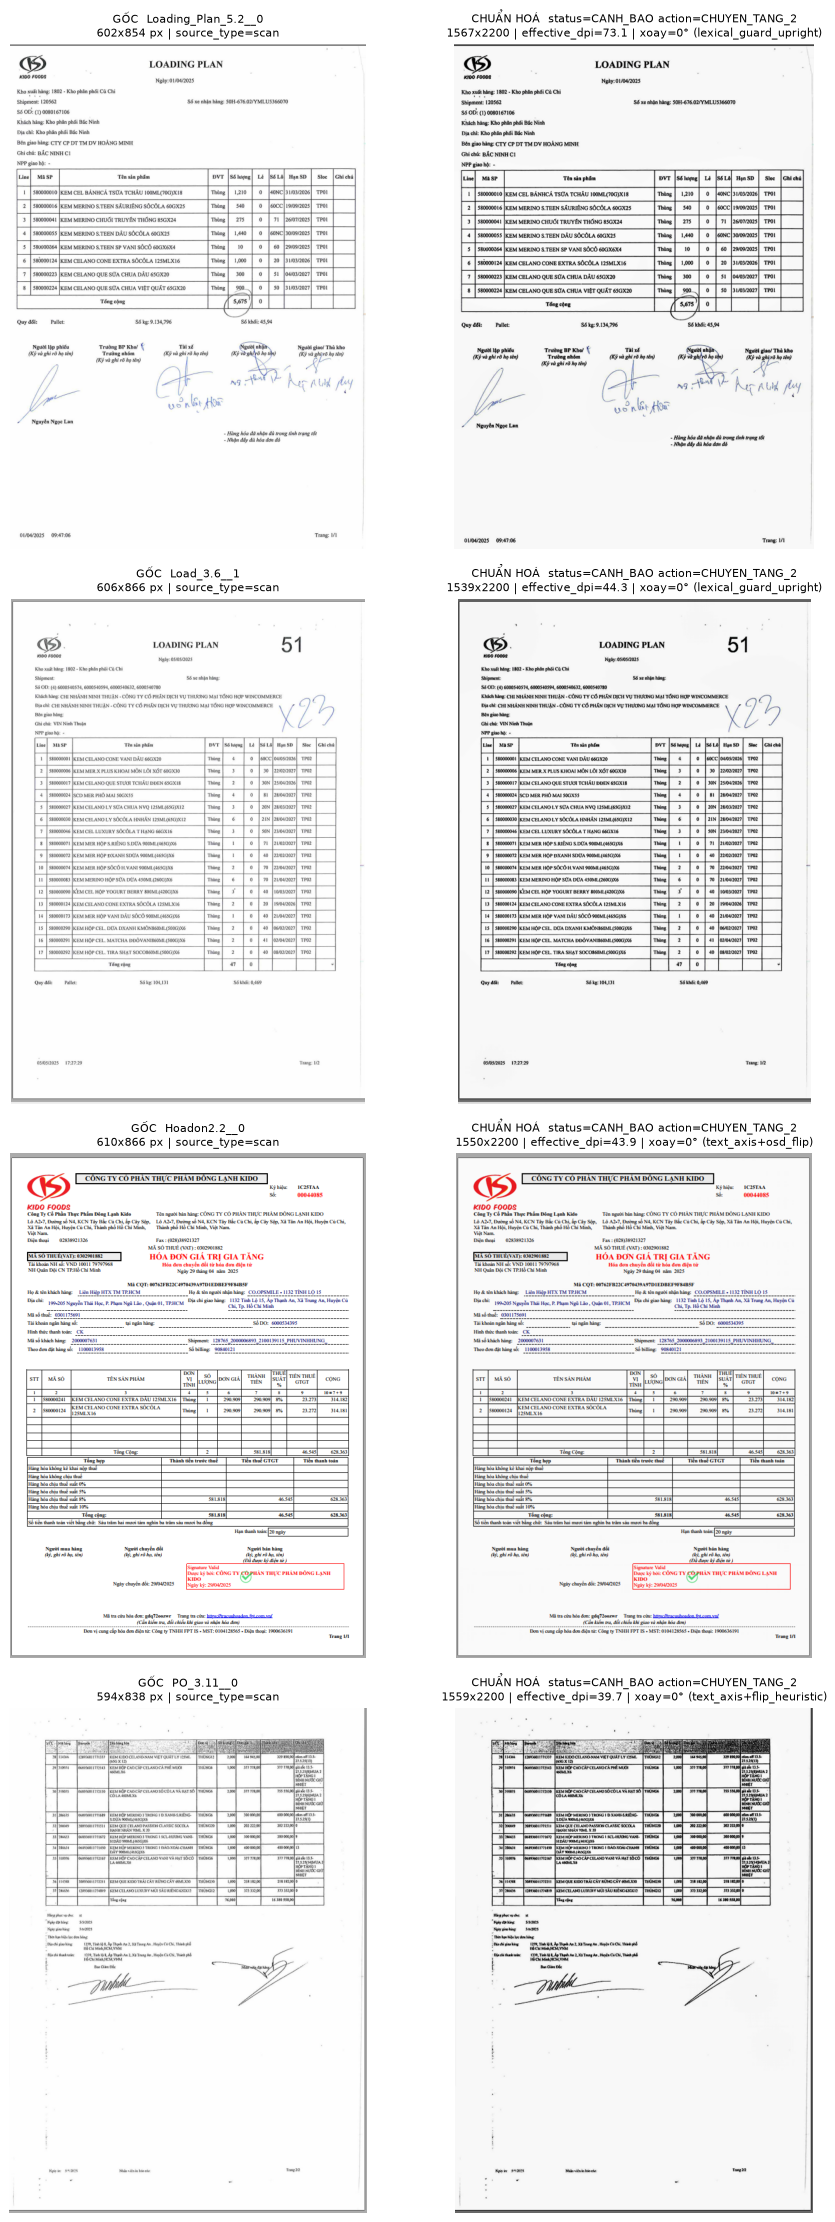

In [7]:
import matplotlib.pyplot as plt

SHOW = ["Loading_Plan_5.2__0", "Load_3.6__1", "Hoadon2.2__0", "PO_3.11__0"]
SHOW += [Path(f).stem for f in df[df.status == "CHUP_LAI"].file if Path(f).stem not in SHOW]

def _rgb(im):
    return cv2.cvtColor(im, cv2.COLOR_BGR2RGB) if im is not None else None

fig, axes = plt.subplots(len(SHOW), 2, figsize=(11, 6.2 * len(SHOW)))
for row, stem in zip(axes, SHOW):
    r = by_name.get(stem + ".png")
    if r is None:
        row[0].set_title(f"{stem}: KHÔNG có JSON"); row[0].axis("off"); row[1].axis("off"); continue
    src = s1.imread_unicode(r["source_file"])
    ip = (r.get("output") or {}).get("image")
    dst = s1.imread_unicode(ip) if ip else None
    q = r.get("quality_output") or {}
    rot = r.get("rotation") or {}
    row[0].imshow(_rgb(src)); row[0].axis("off")
    row[0].set_title(f"GỐC  {stem}\n{src.shape[1]}x{src.shape[0]} px | source_type={r.get('source_type')}", fontsize=9)
    if dst is not None:
        row[1].imshow(_rgb(dst))
        row[1].set_title(f"CHUẨN HOÁ  status={r['status']} action={r['action']}\n"
                         f"{dst.shape[1]}x{dst.shape[0]} | effective_dpi={q.get('effective_dpi')} | "
                         f"xoay={rot.get('coarse_deg')}° ({rot.get('coarse_method')})", fontsize=9)
    else:
        row[1].text(0.02, 0.5, "KHÔNG có ảnh chuẩn hoá\nrejects:\n" + "\n".join(r.get("rejects") or []),
                    fontsize=8, wrap=True, va="center")
        row[1].set_title(f"status={r['status']} action={r['action']}", fontsize=9)
    row[1].axis("off")
plt.tight_layout()
plt.show()

In [8]:
# ink_check trên các trang vừa hiển thị: % pixel đỏ / xanh trước và sau chuẩn hoá (đọc từ JSON)
rows = []
for stem in SHOW:
    r = by_name.get(stem + ".png") or {}
    ic = r.get("ink_check") or {}
    b, a = ic.get("before") or {}, ic.get("after") or {}
    rows.append({"file": stem, "red_before": b.get("red_pixel_pct"), "red_after": a.get("red_pixel_pct"),
                 "blue_before": b.get("blue_pixel_pct"), "blue_after": a.get("blue_pixel_pct"),
                 "warns": len(r.get("warns") or [])})
pd.DataFrame(rows)

,file,red_before,red_after,blue_before,blue_after,warns
0,Loading_Plan_5.2__0,0.0000,0.000,0.1636,0.1359,1
1,Load_3.6__1,0.0000,0.000,0.0243,0.0178,1
2,Hoadon2.2__0,1.9721,1.955,2.8952,2.7669,1
3,PO_3.11__0,0.0000,0.000,0.0000,0.0000,1


## 10. Kiểm tái lập so với một lần chạy trước (`REFERENCE_DIR`)

So nghiêm ngặt từng cặp file giữa `OUT_DIR` và `REFERENCE_DIR`:

* **JSON:** so toàn bộ nội dung, **chỉ bỏ `elapsed_ms`**. Riêng `output.image` chứa tiền tố thư mục
  đầu ra — mỗi phía được chuẩn hoá về `<ROOT>/images/...` theo **thư mục gốc của chính nó**:
  phía mới theo `OUT_DIR`; phía tham chiếu theo `REFERENCE_DIR` **hoặc** gốc lúc sinh ra
  (`KIDO_T1_REFERENCE_ORIGIN_ROOT`, mặc định `output/stage1_out` — vì bản tham chiếu thường là
  bản sao nên JSON vẫn ghi gốc cũ). Phần sau tiền tố giữ nguyên văn; tiền tố không khớp gốc nào
  thì giữ nguyên chuỗi ⇒ bị tính lệch. Cell in rõ các tiền tố đã dùng ở từng phía.
  Mọi trường khác — kể cả `source_file` — giữ nguyên.
* **Ảnh:** giải mã và so **từng pixel** (`np.array_equal`), kèm so SHA-256 byte file.
* Tập tên file hai phía phải trùng nhau.

`REFERENCE_DIR` rỗng ⇒ **BỎ QUA** (không in PASS). `REFERENCE_DIR == OUT_DIR` ⇒ từ chối
(tự so với chính mình là PASS giả).

> Bối cảnh (AGENTS.md 3.E, ĐÍNH CHÍNH 27/09): output Tầng 1 lúc 01:06 **không** tái lập được từ code
> hiện tại (71/71 ảnh, 72/72 JSON lệch số lẻ, không trang nào đổi status/action). Output mới tái lập
> tuyệt đối giữa 3 lần chạy. Cell này là phép kiểm lặp lại được cho khẳng định đó.

In [9]:
def _norm_rec(rec, root, extra_roots=()):
    # Chuẩn hoá `output.image` về dạng tương đối theo thư mục gốc của CHÍNH phía đó.
    # Tiền tố hợp lệ: `root` (thư mục đang đọc) hoặc một trong `extra_roots` — bản tham chiếu là
    # BẢN SAO của một lần chạy trước nên JSON vẫn ghi thư mục gốc lúc sinh ra (vd `output/stage1_out`);
    # thư mục đó được chấp nhận là gốc của phía tham chiếu. Phần sau tiền tố (images/<lô>/<file>)
    # giữ nguyên văn ⇒ lệch thật ở phần này vẫn bị bắt. Tiền tố không khớp gốc nào ⇒ KHÔNG chuẩn hoá,
    # giữ nguyên chuỗi gốc ⇒ bị tính là lệch (không nuốt). Trả về (rec, tiền_tố_đã_dùng | None).
    rec = json.loads(json.dumps(rec))
    rec.pop("elapsed_ms", None)
    used = None
    out = rec.get("output")
    if isinstance(out, dict) and isinstance(out.get("image"), str):
        p = out["image"].replace("\\", "/")
        for r in (root, *extra_roots):
            rt = str(r).replace("\\", "/").rstrip("/") + "/"
            if p.startswith(rt):
                out["image"] = "<ROOT>/" + p[len(rt):]
                used = rt
                break
    return rec, used

def _diff_keys(a, b, prefix=""):
    ks = []
    for k in sorted(set(a) | set(b)):
        va, vb = a.get(k, "<THIẾU>"), b.get(k, "<THIẾU>")
        if isinstance(va, dict) and isinstance(vb, dict):
            ks += _diff_keys(va, vb, prefix + k + ".")
        elif va != vb:
            ks.append(prefix + k)
    return ks

REPRO = {"checked": False}
if REFERENCE_DIR is None:
    print("BỎ QUA kiểm tái lập: REFERENCE_DIR rỗng (đặt KIDO_T1_REFERENCE_DIR để kiểm). KHÔNG phải PASS.")
elif Path(REFERENCE_DIR).resolve() == Path(OUT_DIR).resolve():
    raise AssertionError("REFERENCE_DIR trùng OUT_DIR — tự so với chính mình là PASS giả, từ chối.")
else:
    ref_pages = Path(REFERENCE_DIR) / "pages" / BATCH_ID
    ref_imgs = Path(REFERENCE_DIR) / "images" / BATCH_ID
    a_js = {p.name for p in PAGES_DIR.glob("*.json")}; b_js = {p.name for p in ref_pages.glob("*.json")}
    a_im = {p.name for p in IMAGES_DIR.glob("*.png")}; b_im = {p.name for p in ref_imgs.glob("*.png")}
    print(f"JSON: OUT_DIR {len(a_js)} | REFERENCE {len(b_js)} | chỉ có ở 1 phía: {sorted(a_js ^ b_js)}")
    print(f"Ảnh : OUT_DIR {len(a_im)} | REFERENCE {len(b_im)} | chỉ có ở 1 phía: {sorted(a_im ^ b_im)}")

    # Gốc lúc sinh của bản tham chiếu: runner chính thức ghi vào output/stage1_out (mặc định).
    REF_ORIGIN_ROOT = os.environ.get("KIDO_T1_REFERENCE_ORIGIN_ROOT", "output/stage1_out")
    json_diff, n_path_norm, key_counter, prefix_counter = [], 0, Counter(), Counter()
    for name in sorted(a_js & b_js):
        ra, ta = _norm_rec(json.load(open(PAGES_DIR / name, encoding="utf-8")), OUT_DIR)
        # Phía tham chiếu: gốc là REFERENCE_DIR, hoặc gốc lúc sinh ra (bản sao của output/stage1_out).
        rb, tb = _norm_rec(json.load(open(ref_pages / name, encoding="utf-8")), REFERENCE_DIR,
                           extra_roots=(REF_ORIGIN_ROOT,))
        n_path_norm += int(bool(ta and tb))
        prefix_counter[("OUT", ta)] += 1
        prefix_counter[("REF", tb)] += 1
        if ra != rb:
            ks = _diff_keys(ra, rb)
            key_counter.update(k.split(".")[0] for k in ks)
            json_diff.append((name, ks[:8]))

    img_pix_diff, img_byte_diff = [], 0
    for name in sorted(a_im & b_im):
        pa, pb = IMAGES_DIR / name, ref_imgs / name
        if hashlib.sha256(pa.read_bytes()).digest() != hashlib.sha256(pb.read_bytes()).digest():
            img_byte_diff += 1
        ia, ib = s1.imread_unicode(str(pa)), s1.imread_unicode(str(pb))
        if ia is None or ib is None or ia.shape != ib.shape or not np.array_equal(ia, ib):
            img_pix_diff.append(name)

    print(f"output.image được chuẩn hoá tiền tố thư mục ở {n_path_norm}/{len(a_js & b_js)} JSON (cả hai phía)")
    for (side, pref), n in sorted(prefix_counter.items(), key=lambda x: (x[0][0], str(x[0][1]))):
        print(f"  tiền tố {side}: {pref if pref else '(KHÔNG khớp gốc nào — giữ nguyên, sẽ tính lệch)'} × {n}")
    print(f"JSON lệch (bỏ elapsed_ms): {len(json_diff)}/{len(a_js & b_js)}")
    if json_diff:
        print("  khoá cấp 1 bị lệch (đếm theo trang):", dict(key_counter))
        for name, ks in json_diff[:15]:
            print(f"  - {name}: {ks}")
    print(f"Ảnh lệch pixel: {len(img_pix_diff)}/{len(a_im & b_im)} | ảnh lệch byte (SHA-256): {img_byte_diff}")
    for name in img_pix_diff[:15]:
        print("  -", name)
    REPRO = {"checked": True, "json_diff": len(json_diff), "img_pixel_diff": len(img_pix_diff),
             "img_byte_diff": img_byte_diff, "only_one_side": sorted((a_js ^ b_js) | (a_im ^ b_im))}
    print("\nKẾT LUẬN:", "DIFF = 0 (JSON + ảnh + tập file)" if (not json_diff and not img_pix_diff
          and not REPRO["only_one_side"]) else "CÓ LỆCH — xem chi tiết ở trên, không che.")

JSON: OUT_DIR 72 | REFERENCE 72 | chỉ có ở 1 phía: []
Ảnh : OUT_DIR 72 | REFERENCE 72 | chỉ có ở 1 phía: []
output.image được chuẩn hoá tiền tố thư mục ở 72/72 JSON (cả hai phía)
  tiền tố OUT: output/stage1_out/ × 72
  tiền tố REF: output/stage1_out/ × 72
JSON lệch (bỏ elapsed_ms): 0/72
Ảnh lệch pixel: 0/72 | ảnh lệch byte (SHA-256): 0

KẾT LUẬN: DIFF = 0 (JSON + ảnh + tập file)


## 11. Ngoài phạm vi notebook này (có trong module, không chạy ở đây)

* **Bộ sinh ảnh chụp mô phỏng** (`synth_photo`, `run_demo` trong `stage1_normalizer.py`) và 2 lô
  `LO_MO_PHONG_001` / `LO_SCAN_MAU` trong `output/stage1_out/` là sản phẩm của bản notebook cũ, **không**
  thuộc artifact chính thức Tầng 2 đọc (`pages/form_samples/`). Notebook này không chạy lại chúng.
* **Golden set 4 góc gán tay** (`golden.json`) — **chưa có**. IoU tứ giác hiện chỉ so với mặt nạ do chính
  hệ thống sinh ra (tự soi gương). Muốn biết tứ giác đúng thật phải có 4 góc người gán tay.
* **Trích ảnh từ Excel** (`extract_forms_from_xlsx`, `get_form_catalog()`): 72 ảnh trong
  `output/form_samples/` và `output/form_catalog.json` đã có sẵn; notebook không trích lại.

## 12. Việc cần làm khi có ảnh thật

1. Quét 40–60 chứng từ thật ở 300 DPI — đường găng, chặn mọi việc khác.
2. Gán nhãn tay 4 góc + trạng thái mong đợi → `golden.json`.
3. Lập ma trận nhầm lẫn 3 mức, rồi mới chỉnh các ngưỡng nhạy nhất
   (`ink_outside_reject`, `agreement_reject`, `blur_reject`, `glare_reject_pct`, `dpi_reject`).
4. Theo dõi tỉ lệ bị bắt chụp lại; vượt ~15% là đang quá chặt.

**Chốt chặn không nhân nhượng:** "cho qua nhầm" nghiêm trọng hơn "loại oan" — ảnh mất chữ ký chui vào
Tầng 4 sẽ ra kết luận "đạt" trên bộ chứng từ thiếu. Nhưng DPI thấp đơn lẻ **không** phải lý do loại
(mục 3). **Phương án B** nếu tách giấy/nền không ổn định trên ảnh thật: phát tấm bìa tối màu khổ A3 để
đặt chứng từ khi chụp — biến bài toán mơ hồ thành xác định.